In [33]:
building = 0
time = 24
price = 'Realistic'

# Setup

In [34]:
import torch
import pandas as pd
import numpy as np
import math

import src.data.dataprep as prep
import src.data.featurisation as features

from src.models.lstm import LSTM
from src.models.lstmopt import LSTMOPT
from src.models.lstmopt import CVXLayer

from src.training.training import  Training as Training
from src.training.training_opt import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.tensors.tensorisation as tensor

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error as mse

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [35]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h', price=price)

In [36]:
featurisation = features.Featurisation(nl_data)
nl_data = featurisation.cyclic_features(yearly=False)[0]
nl_data.head()

,load,solar_energy,net_load,offtake,injection,cost,hour_sin,hour_cos
2018-07-01 00:00:00,0.905,0.0,0.905,0.18878,0.030,0.170846,0.000000,1.000000
2018-07-01 01:00:00,0.404,0.0,0.404,0.18178,0.024,0.073439,0.258819,0.965926
2018-07-01 02:00:00,0.345,0.0,0.345,0.17278,0.018,0.059609,0.500000,0.866025
2018-07-01 03:00:00,0.370,0.0,0.370,0.16278,0.010,0.060229,0.707107,0.707107
2018-07-01 04:00:00,0.552,0.0,0.552,0.16478,0.012,0.090959,0.866025,0.500000


In [37]:
battery_capacity = round(nl_data['load'].resample('YE').sum().max() * 1.1 / 1000,1)
battery_capacity

8.8

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters

In [39]:
# Base parameters
max_charge = battery_capacity/2.7
max_discharge = max_charge
layers = 3
neurons = 200
features = 3
train_test_split = 0.6

past_features = ['solar_energy']
opt_future_features = ['hour_sin','hour_cos','load','offtake','injection']
domain_min = [None, None, None, 0, 0, 0, 0]
domain_max = [None, None, None, 1, 1, 1, 1]

In [40]:
pvb_system = pvb.PV_battery(nl_data, building, battery_capacity, max_charge, max_discharge, self_consumption=False)

In [41]:
lowest_T = 0

In [9]:
dictionary_list_perfect = pvb_system.execute_optimization(time,lowest_T,'Perfect',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_naive = pvb_system.execute_optimization(time,lowest_T,'Naive',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_lstm = pvb_system.execute_optimization(time,lowest_T,'LSTM',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_cvx = pvb_system.execute_optimization(time,lowest_T,'CVX',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_lstm_cvx = pvb_system.execute_optimization(time,lowest_T,'LSTM_CVX',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)

Setting up optimization for 0:00
Setting up optimization for 1:00
Setting up optimization for 2:00
Setting up optimization for 3:00
Setting up optimization for 4:00
Setting up optimization for 5:00
Setting up optimization for 6:00
Setting up optimization for 7:00
Setting up optimization for 8:00
Setting up optimization for 9:00
Setting up optimization for 10:00
Setting up optimization for 11:00
Setting up optimization for 12:00
Setting up optimization for 13:00
Setting up optimization for 14:00
Setting up optimization for 15:00
Setting up optimization for 16:00
Setting up optimization for 17:00
Setting up optimization for 18:00
Setting up optimization for 19:00
Setting up optimization for 20:00
Setting up optimization for 21:00
Setting up optimization for 22:00
Setting up optimization for 23:00
Setting up optimization for 0:00
Setting up optimization for 1:00
Setting up optimization for 2:00
Setting up optimization for 3:00
Setting up optimization for 4:00
Setting up optimization for 5

In [10]:
hours = range(0,24)

In [11]:
tot_cost_perfect = []
tot_cost_lstm = []
tot_cost_cvx_lstm = []
tot_cost_cvx = []

for hour in hours:
    perfect_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_perfect[hour]['imp'][:,0]) - (dictionary_list_perfect[hour]['injection'][:,0] * dictionary_list_perfect[hour]['exp'][:,0])
    naive_cost = (dictionary_list_naive[hour]['offtake'][:,0] * dictionary_list_naive[hour]['imp'][:,0]) - (dictionary_list_naive[hour]['injection'][:,0] * dictionary_list_naive[hour]['exp'][:,0])
    lstm_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_lstm[hour]['imp'][:,0]) - (dictionary_list_lstm[hour]['injection'][:,0] * dictionary_list_lstm[hour]['exp'][:,0])
    cvx_cost = (dictionary_list_cvx[hour]['offtake'][:,0] * dictionary_list_cvx[hour]['imp'][:,0]) - (dictionary_list_cvx[hour]['injection'][:,0] * dictionary_list_cvx[hour]['exp'][:,0])
    lstm_cvx_cost = (dictionary_list_lstm_cvx[hour]['offtake'][:,0] * dictionary_list_lstm_cvx[hour]['imp'][:,0]) - (dictionary_list_lstm_cvx[hour]['injection'][:,0] * dictionary_list_lstm_cvx[hour]['exp'][:,0])
    
    tot_cost_perfect.append(perfect_cost)
    tot_cost_lstm.append(lstm_cost)
    tot_cost_cvx_lstm.append(lstm_cvx_cost)
    tot_cost_cvx.append(cvx_cost)

In [12]:
np.sum(tot_cost_perfect), np.sum(tot_cost_lstm), np.sum(tot_cost_cvx_lstm), np.sum(tot_cost_cvx)

(143.0958737655847, 246.60348944936763, 208.90823167888624, 221.6590499623486)

In [13]:
pilot_day = 0
model = dictionary_list_lstm_cvx
variable = 'pv'

final_schedule = np.empty(len(model))

for i in range(len(model)):
    final_schedule[i] = model[i][variable][pilot_day][0]

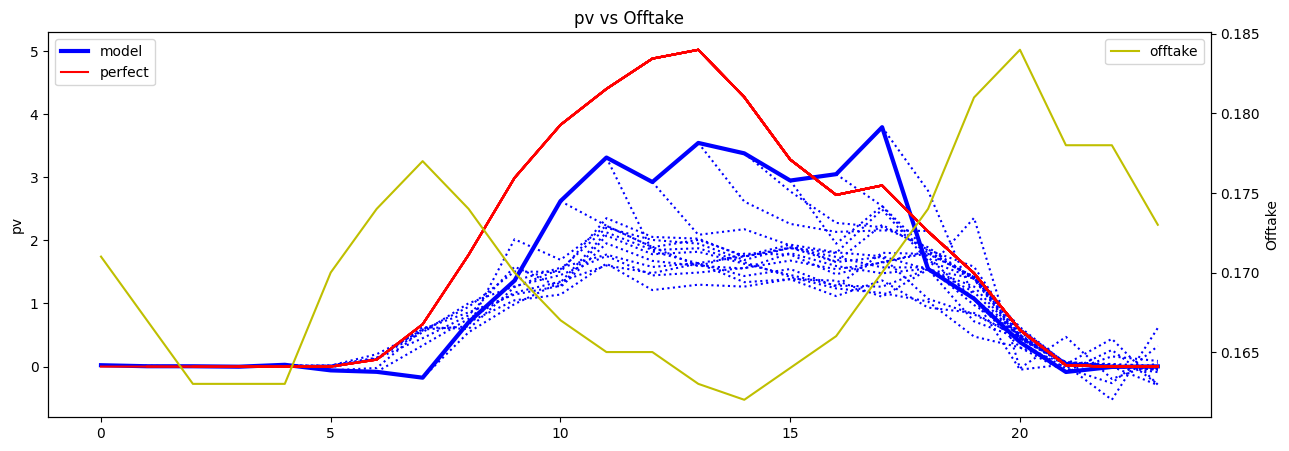

In [14]:
plt.figure(figsize=(15,5))

# Primary axis
ax1 = plt.gca()

# Plot energy data on ax1
ax1.plot(model[0][variable][pilot_day], linestyle=':', color='b')
for i in range(1, len(model)):
    ax1.plot(np.pad(model[i][variable][pilot_day], (i, 0), mode='constant', constant_values=np.nan), linestyle=':', color='b')

ax1.plot(final_schedule, color='b', linewidth=3, label='model')

ax1.plot(dictionary_list_perfect[0][variable][pilot_day], color='r', label='perfect')
for i in range(1, len(dictionary_list_perfect)):
    ax1.plot(np.pad(dictionary_list_perfect[i][variable][pilot_day], (i, 0), mode='constant', constant_values=np.nan), color='r')

ax1.set_ylabel(variable)
ax1.legend(loc='upper left')

# Secondary y-axis
ax2 = ax1.twinx()

# Plot offtake on ax2
ax2.plot(model[0]['offtake'][pilot_day], color='y', label='offtake')
ax2.set_ylabel('Offtake')

# Optional: add second legend
ax2.legend(loc='upper right')

plt.title(variable + " vs Offtake")
plt.show()